In [1]:
import os
os.chdir('../../..')

print(os.listdir())

['.DS_Store', 'uv.lock', 'config', 'wandb.py', 'pyproject.toml', 'tests', 'utils', 'models', 'README.md', 'results', '.gitignore', 'figures', '.venv', 'scripts', '.python-version', 'api', 'report', '.git', 'main.py', 'data', 'notebooks', 'src']


# This workbook contains results for the Euclidean baseline clustering

In [2]:
import chemiscope
from ase import Atoms  
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import polars as pl
from collections import Counter
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from rdkit import Chem
from loguru import logger
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from src.datasets import QM9Dataset
from sklearn.manifold import TSNE

2026-02-27 13:25:52.577 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_all_descriptors(include_chemprop=True)

2026-02-27 13:25:53.992 | INFO     | src.datasets:load:62 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-27 13:25:54.008 | INFO     | src.datasets:add_all_descriptors:272 - Adding all descriptors to QM9 dataframe...
2026-02-27 13:25:54.008 | INFO     | src.features:compute_morgan_fingerprints:58 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-02-27 13:25:57.373 | INFO     | src.features:compute_selfies_transformer:75 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...
2026-02-27 13:25:57.373 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-02-27 13:26:13.760 | INFO     | src.features:compute_selfies_onehot:117 - Computing One-Hot Encodings...
2026-02-27 13:26:14.574 | INFO     | src.features:compute_soap:140 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-02-27 13:26:19.829 | SUCCESS  | src.datasets:add_soap:223 - Added SOAP embeddings.
2026-02-27 13:26:19.830 | INFO     | src.features:compute_acsf:170 - Computing ACSF (rcut=6.0)...
2026-02-27 13:26:24.198 | SUCCESS  | src.datasets:add_acsf:233 - Added ACSF embeddings.
2026-02-27 13:26:24.199 | INFO     | src.features:compute_chemprop_embeddings:203 - Computing Chemprop embeddings on mps...
2026-02-27 13:26:24.199 | WARNING  | src.features:compute_chemprop_embeddings:211 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-02-27 13:26:25.664 | SUCCESS  | src.datasets:add_all_descriptors:285 - Finished adding all requested descriptors.


In [4]:
qm9.df["selfies", "structure_class"][0]["selfies"].to_list()

['[H][C][Branch1][C][H][Branch1][C][H][C][#C][C][Branch1][C][H][Branch1][C][H][C][Branch1][C][H][Branch1][C][H][H]']

In [5]:
X_morgan = np.array(qm9.df['morgan_fingerprint'].to_list())
X_onehot = np.array(qm9.df['selfies_onehot'].to_list())
X_onehot = X_onehot.reshape(X_onehot.shape[0], -1)
X_transformer = np.array(qm9.df["selfies_transformer"].to_list())
X_chemprop = np.array(qm9.df["chemprop_embedding"].to_list())
X_soap = np.array(qm9.df["soap_embedding"].to_list())
X_acsf = np.array(qm9.df["acsf_embedding"].to_list())

In [6]:
from config.states import get_num_clusters

embeddings = {
    "onehot": X_onehot,
    "morgan": X_morgan,
    "transformer": X_transformer,
    "chemprop": X_chemprop,
    "soap": X_soap,
    "acsf": X_acsf,
}

cluster_labels = {}

for label, X in embeddings.items():
    n_clusters = get_num_clusters(label)

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10,
    )

    cluster_labels[f"{label}_labels"] = model.fit_predict(X)

qm9.df = qm9.df.with_columns(**cluster_labels)

df = qm9.df.drop([
    "morgan_fingerprint",
    "selfies_onehot",
    "selfies_transformer",
    "chemprop_embedding",
    "soap_embedding",
    "acsf_embedding",
])

df.write_csv("report/qm9/euclidean_baseline/csv/qm9_clusterlabels.csv")

In [7]:
def get_structures():
    # Extract both the IDs and the SMILES strings
    mol_ids = qm9.df["mol_id"].to_list()
    smiles_list = qm9.df["canonical_smiles"].to_list()
    
    structures = []  
    valid_indices = [] # We need to track this (see warning below)
    
    for i, (mol_id, s) in enumerate(zip(mol_ids, smiles_list)):
        if s is None:
            print(f"Skipping {mol_id}: SMILES is missing.")
            continue
            
        mol = Chem.MolFromSmiles(s)
        if mol is None: 
            print(f"Skipping {mol_id}: RDKit could not parse SMILES.")
            continue
            
        mol = Chem.AddHs(mol)

        res = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        if res != 0: 
            print(f"Skipping {mol_id}: Failed to generate 3D conformer.")
            continue

        conf = mol.GetConformer()
        positions = conf.GetPositions()
        numbers = [a.GetAtomicNum() for a in mol.GetAtoms()]
        
        atoms = Atoms(numbers=numbers, positions=positions)
        structures.append(atoms)
        valid_indices.append(i)
        
    return structures, valid_indices


def write_chemiscope(X, label):

    n = get_num_clusters(label)

    structures, valid_indicies = get_structures()

    X = X[valid_indicies]
    model = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    properties = {
        "PCA 1": X_pca[:, 0],
        "PCA 2": X_pca[:, 1],
        "Cluster": labels,
    }

    output_path = "report/qm9/euclidean_baseline/csv/visualization.json.gz"

    chemiscope.write_input(
        output_path,
        structures=structures,
        properties=properties,
    )
    return output_path

output_path = write_chemiscope(X_chemprop, 'chemprop')

- Oxygen: Red
- Nitrogen: Blue
- Hydrogen: White
- Sulfur: Yellow
- Carbon : Grey / Black

In [8]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 13, 'data': 'structure-0'}, {'size': 16…

Processing: One-Hot...
Processing: Morgan...
Processing: Transformer...
Processing: ChemProp...
Processing: SOAP...
Processing: ACSF...

Saved to report/qm9/appendix/cluster_metrics.png


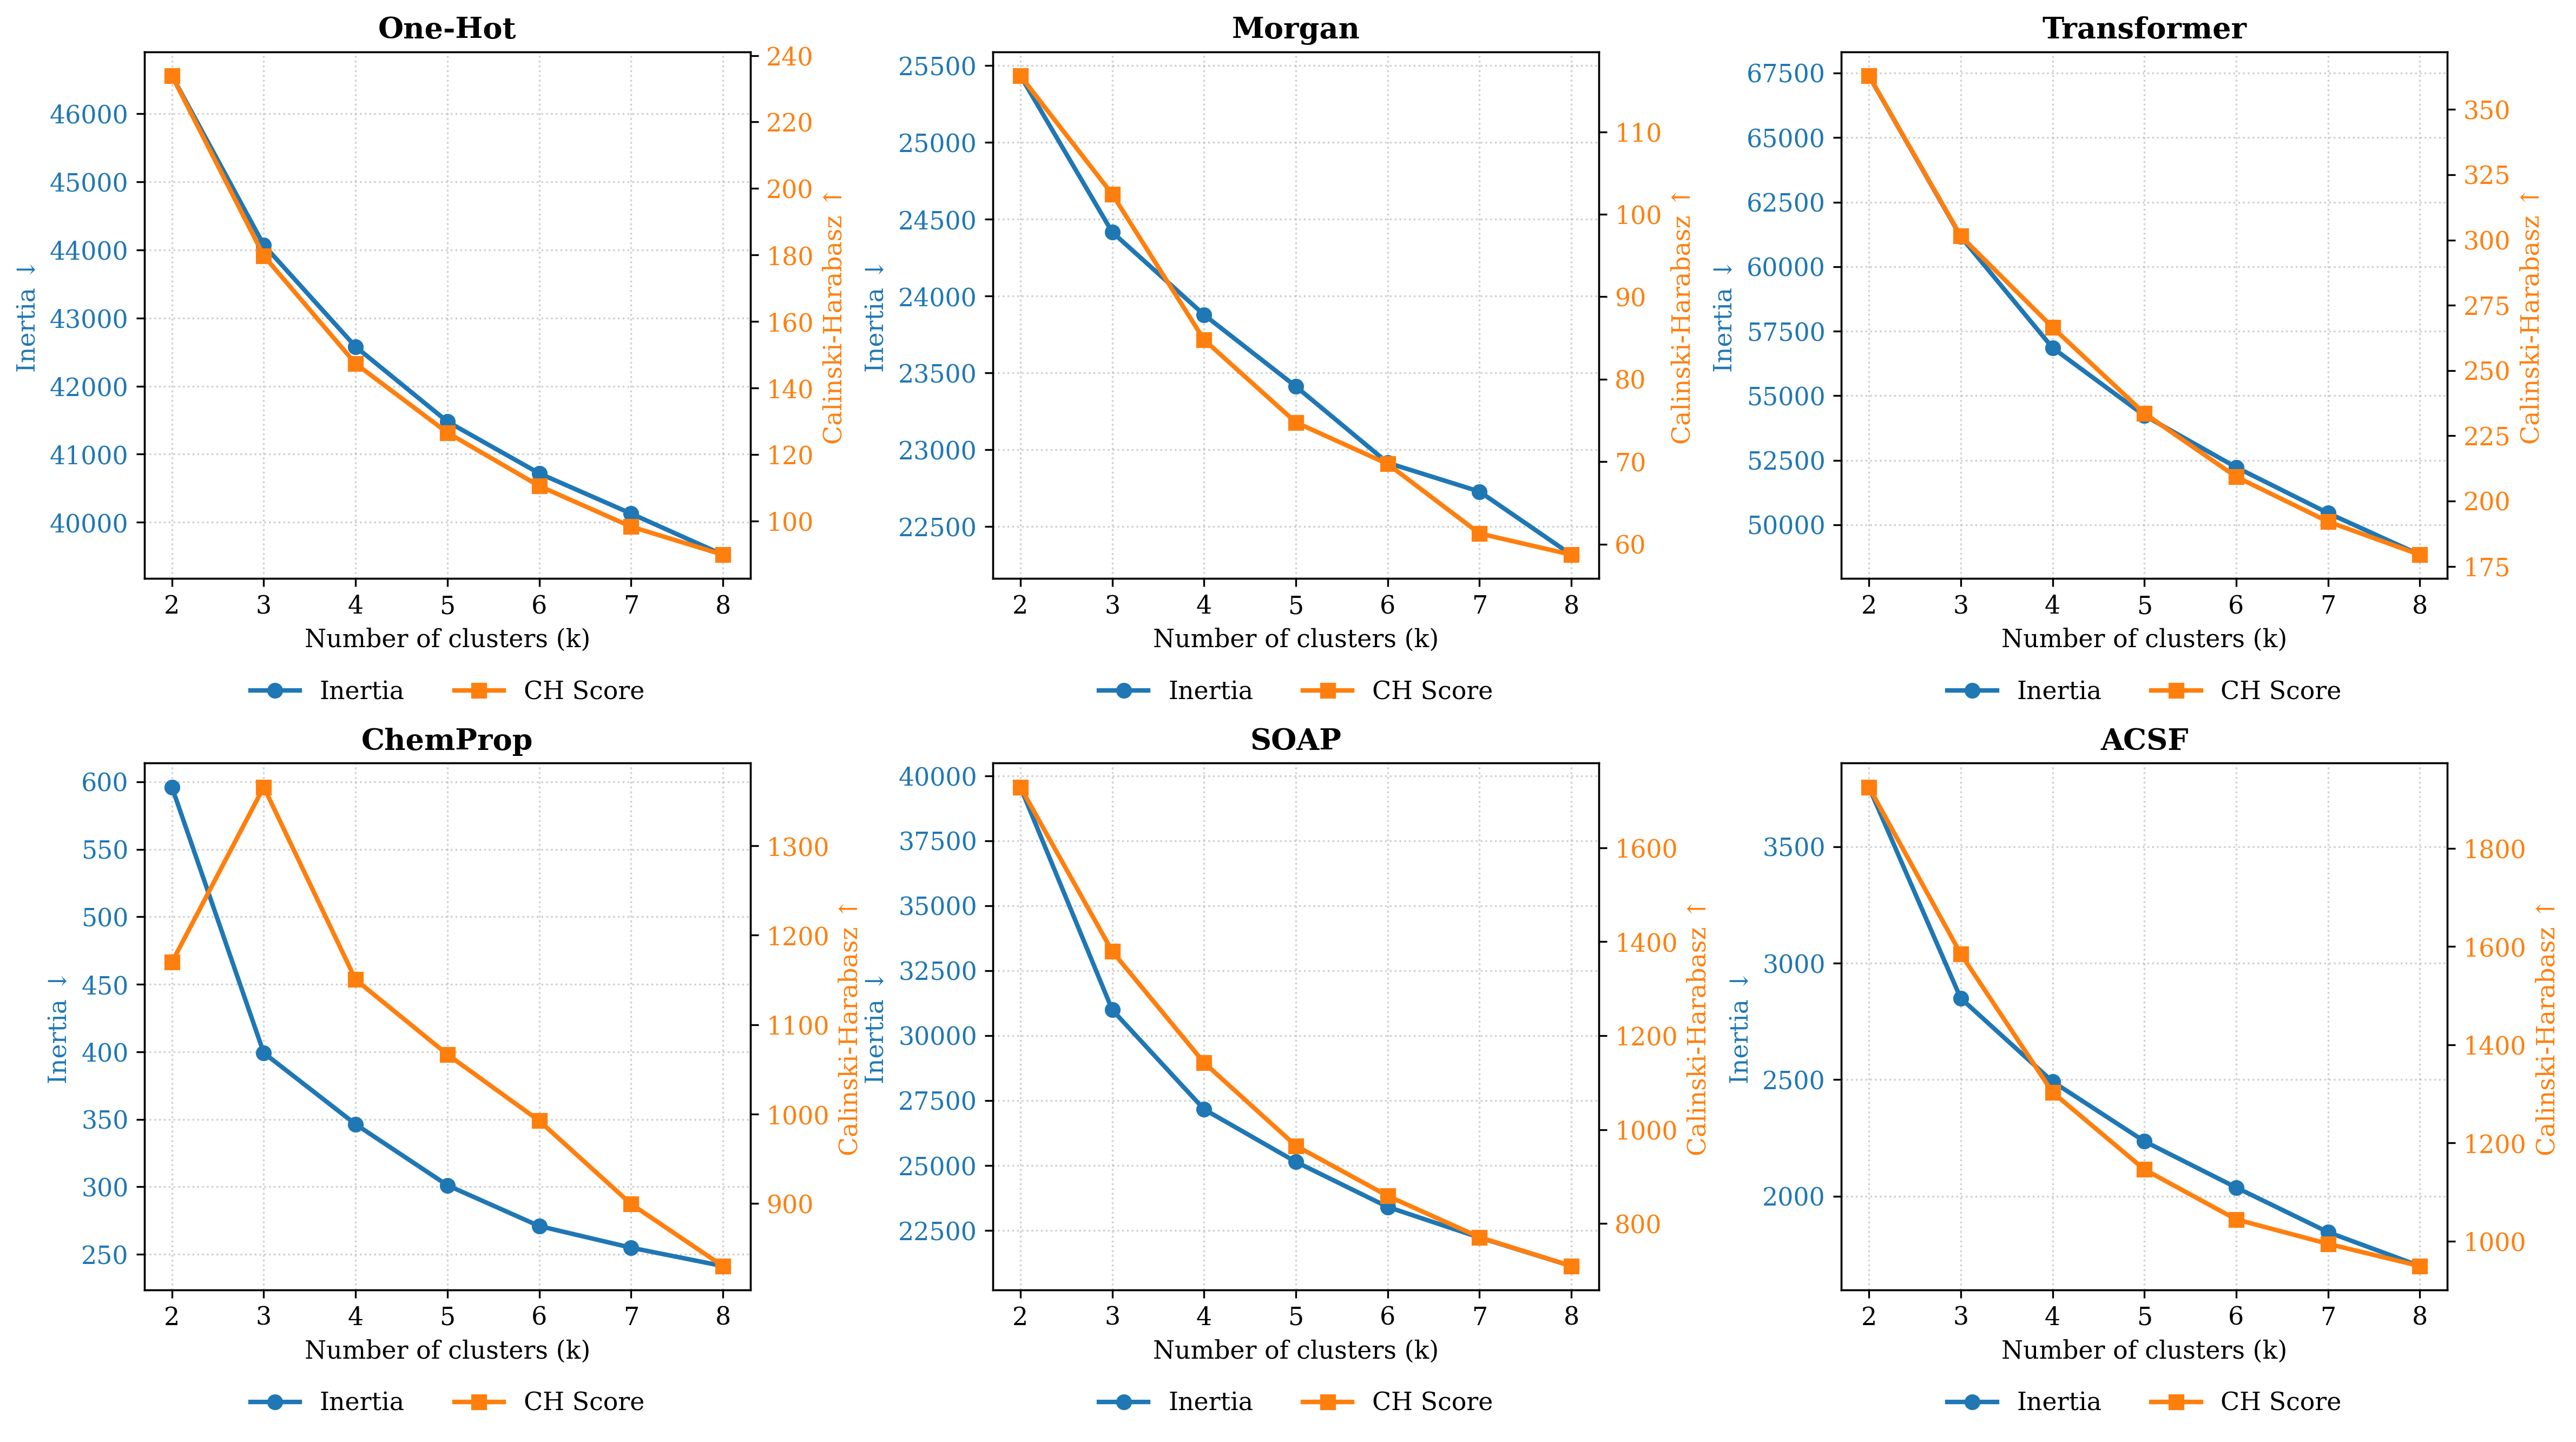

In [9]:
def plot_individual_clustering_metrics(embeddings_dict, max_k=8, save_path=None):
    # Set overall styling for a clean, academic look
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    })

    k_values = list(range(2, max_k + 1))
    
    # Create a 2x3 grid of subplots for the 6 embeddings
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=300)
    axes = axes.flatten()

    for idx, (name, X) in enumerate(embeddings_dict.items()):
        print(f"Processing: {name}...")
        ax1 = axes[idx]
        
        inertia_vals = []
        ch_vals = []
        
        for k in k_values:
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = model.fit_predict(X)
            
            inertia_vals.append(model.inertia_)
            ch_vals.append(calinski_harabasz_score(X, labels))
            
        # 1. Plot Inertia on the primary (left) y-axis
        color1 = '#1f77b4' # Muted Blue
        ax1.set_title(name, fontweight='bold')
        ax1.set_xlabel("Number of clusters (k)")
        ax1.set_ylabel("Inertia ↓", color=color1)
        line1 = ax1.plot(k_values, inertia_vals, marker='o', color=color1, linewidth=2, label="Inertia")
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.set_xticks(k_values)
        ax1.grid(True, linestyle=":", alpha=0.6)
        
        # 2. Plot CH on the secondary (right) y-axis
        ax2 = ax1.twinx()
        color2 = '#ff7f0e' # Muted Orange
        ax2.set_ylabel("Calinski-Harabasz ↑", color=color2)
        line2 = ax2.plot(k_values, ch_vals, marker='s', color=color2, linewidth=2, label="CH Score")
        ax2.tick_params(axis='y', labelcolor=color2)
        
        # 3. Combine legends at the bottom of each subplot
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

    # Hide any unused subplots if you pass fewer than 6 embeddings
    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    # Add a little extra vertical space between rows for the legends
    plt.subplots_adjust(hspace=0.35, wspace=0.4)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"\nSaved to {save_path}")
        
    plt.show()

embeddings = {
    "One-Hot": X_onehot,
    "Morgan": X_morgan,
    "Transformer": X_transformer,
    "ChemProp": X_chemprop,
    "SOAP": X_soap,
    "ACSF": X_acsf
}

plot_individual_clustering_metrics(embeddings, save_path="report/qm9/appendix/cluster_metrics.png")

# Cluster composition analysis

In [10]:
#print(df["morgan_labels"].value_counts(), df["onehot_labels"].value_counts(), df["transformer_labels"].value_counts(), df["chemprop_labels"].value_counts(), df["soap_labels"].value_counts(), df["acsf_labels"].value_counts())

In [11]:
properties_to_analyze = [
        "mol_weight", "logp", "tpsa", 
        "num_heavy_atoms", "num_rings", "num_aromatic_rings", 
        "num_rotatable_bonds", "fraction_csp3", "h_bond_donors", "h_bond_acceptors",
        "branching_index", "num_sp_carbons", "num_sp2_carbons", "num_sp3_carbons", "main_chain_length", "raw_token_count",
        "fr_benzene", "fr_alcohol", "fr_phenol", "fr_amine", "fr_amide", "fr_carboxylic_acid", "fr_ester", "fr_ketone", "fr_ether", "fr_nitro", "fr_halogen"
    ]

In [12]:
import polars as pl
import logging
from pathlib import Path
from loguru import logger

def generate_cluster_report(df: pl.DataFrame, label_col: str, output_csv: str):
    """
    Generate a cluster profile report for a given label column.

    Args:
        df: Polars DataFrame containing molecule properties and cluster labels.
        label_col: Column name containing cluster labels.
        output_csv: Path to save the CSV report.
    Returns:
        summary_df: Pandas DataFrame with aggregated cluster statistics.
    """
    logger.info(f"Generating report for: '{label_col}'...")

    # Identify numeric columns for aggregation

    properties_to_analyze = [
        "mol_weight", "logp", "tpsa", 
        "num_heavy_atoms", "num_rings", "num_aromatic_rings", 
        "num_rotatable_bonds", "fraction_csp3", "h_bond_donors", "h_bond_acceptors",
        "branching_index", "num_sp_carbons", "num_sp2_carbons", "num_sp3_carbons", "main_chain_length", "raw_token_count",
        "fr_benzene", "fr_alcohol", "fr_phenol", "fr_amine", "fr_amide", "fr_carboxylic_acid", "fr_ester", "fr_ketone", "fr_ether", "fr_nitro", "fr_halogen"
    ]

    # print which of these columns are not numeric
    non_numeric_cols = [c for c in properties_to_analyze if c not in df.columns or not pl.Float64 in [df[c].dtype, df[c].dtype.__class__]]

    df = df.with_columns([pl.col(c).cast(pl.Float64) for c in properties_to_analyze])
    if non_numeric_cols:
        logger.warning(f"Non-numeric columns in properties_to_analyze: {non_numeric_cols}")

    numeric_cols = [c for c in df.columns if c != label_col and pl.Float64 in [df[c].dtype, df[c].dtype.__class__]]
    
    # Alternatively, if you have a predefined list of properties to analyze:
    # numeric_cols = [p for p in properties_to_analyze if p in df.columns]

    if not numeric_cols:
        logger.warning("No numeric columns found for aggregation.")
        return None

    # Ensure all numeric columns are Float64
    df = df.with_columns([pl.col(c).cast(pl.Float64) for c in numeric_cols])

    # Build aggregation expressions: mean per property + molecule count
    agg_exprs = [pl.col(c).mean().alias(f"avg_{c}") for c in numeric_cols]
    agg_exprs.append(pl.len().alias("molecule_count"))

    # Perform groupby and aggregation
    summary = (
        df.group_by(label_col)
        .agg(agg_exprs)
        .sort(label_col)
    )

    # Convert to Pandas and set label_col as index
    summary_df = summary.to_pandas().set_index(label_col)

    # Ensure output directory exists
    Path(output_csv).parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(output_csv)

    logger.success(f"Saved: {output_csv}")
    return summary_df

# Example usage for multiple embeddings
for embedding in ["onehot", "morgan", "transformer", "chemprop", "soap", "acsf"]:
    generate_cluster_report(
        df,
        label_col=f"{embedding}_labels",
        output_csv=f"report/qm9/euclidean_baseline/csv/{embedding}_profile.csv"
    )

2026-02-27 13:26:58.873 | INFO     | __main__:generate_cluster_report:17 - Generating report for: 'onehot_labels'...
2026-02-27 13:26:58.883 | WARNING  | __main__:generate_cluster_report:34 - Non-numeric columns in properties_to_analyze: ['mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 'num_rings', 'num_aromatic_rings', 'num_rotatable_bonds', 'h_bond_donors', 'h_bond_acceptors', 'branching_index', 'num_sp_carbons', 'num_sp2_carbons', 'num_sp3_carbons', 'main_chain_length', 'raw_token_count', 'fr_benzene', 'fr_alcohol', 'fr_phenol', 'fr_amine', 'fr_amide', 'fr_carboxylic_acid', 'fr_ester', 'fr_ketone', 'fr_ether', 'fr_nitro', 'fr_halogen']
2026-02-27 13:26:58.928 | SUCCESS  | __main__:generate_cluster_report:66 - Saved: report/qm9/euclidean_baseline/csv/onehot_profile.csv
2026-02-27 13:26:58.929 | INFO     | __main__:generate_cluster_report:17 - Generating report for: 'morgan_labels'...
2026-02-27 13:26:58.929 | WARNING  | __main__:generate_cluster_report:34 - Non-numeric columns in pr

In [13]:
os.listdir()

['.DS_Store',
 'uv.lock',
 'config',
 'wandb.py',
 'pyproject.toml',
 'tests',
 'utils',
 'models',
 'README.md',
 'results',
 '.gitignore',
 'figures',
 '.venv',
 'scripts',
 '.python-version',
 'api',
 'report',
 '.git',
 'main.py',
 'data',
 'notebooks',
 'src']

In [14]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_transformer,selfies_onehot,soap_embedding,acsf_embedding,chemprop_embedding,onehot_labels,morgan_labels,transformer_labels,chemprop_labels,soap_labels,acsf_labels
str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[f64],list[list[i64]],list[f64],list[f64],list[f64],i32,i32,i32,i32,i32,i32
"""qm9_115""","""[H]C([H])([H])C#CC([H])([H])C(…","""[H]C([H])([H])C#CC([H])([H])C(…","""[H][C][Branch1][C][H][Branch1]…",13,"""Acyclic""",68,1,0,5,0,0,1,0.6,0,0,3,2,0,3,6,25,0,0,0,0,0,0,0,0,0,0,0,0.078,53.93,-6.533453,1.717039,8.253213,652.481201,3.068383,-5311.57373,-5311.387207,-5311.361328,-5312.428711,22.115,-53.353561,-53.667633,-53.976101,-49.909634,20.506491,2.07478,1.95249,"[0, 0, … 0]","[0.100746, 0.482768, … 0.051405]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.142309, 0.378762, … 0.0]","[3.023262, 1.238791, … 0.0]","[0.309064, 0.0, … 0.071892]",0,0,0,1,0,1
"""qm9_515""","""[H]C#CC([H])([H])C([H])([H])C(…","""[H]C#CC([H])([H])C([H])([H])C(…","""[H][C][#C][C][Branch1][C][H][B…",16,"""Acyclic""",82,1,0,6,0,0,3,0.666667,0,0,4,2,0,4,7,32,0,0,0,0,0,0,0,0,0,0,0,0.835,62.82,-7.017817,1.597308,8.615125,950.827209,3.842928,-6380.378906,-6380.170898,-6380.145508,-6381.235352,26.865,-65.06926,-65.477814,-65.863396,-60.651299,14.85379,1.31677,1.24669,"[0, 0, … 0]","[0.177087, 0.508516, … 0.040071]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.144923, 0.390263, … 0.0]","[4.27486, 1.210497, … 0.0]","[0.329895, 0.0, … 0.036147]",3,0,0,1,2,2
"""qm9_1370""","""[H]C(=O)N(C([H])([H])[H])C([H]…","""[H]C(=O)N(C([H])([H])[H])C([H]…","""[H][C][=Branch1][C][=O][N][Bra…",13,"""Acyclic""",98,0,44,7,0,0,2,0.5,0,2,4,1,1,2,5,25,0,0,0,0,1,0,0,0,0,0,3,3.2465,56.220001,-7.377007,-0.035375,7.344353,848.353699,2.755343,-9269.991211,-9269.786133,-9269.759766,-9270.869141,25.108999,-55.643944,-55.939812,-56.248199,-51.973454,5.91579,1.51412,1.39501,"[0, 0, … 0]","[-0.18989, 0.425525, … -0.111281]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.106482, 0.28832, … 0.0]","[2.924242, 0.909693, … 0.0]","[0.308376, 0.0, … 0.037149]",0,0,1,1,0,1
"""qm9_50""","""[H]C1=NC([H])=C([H])N1[H]""","""[H]c1nc([H])n([H])c1[H]""","""[H][C][N][=C][Branch1][C][H][N…",9,"""Aromatic""",68,0,28,5,1,1,0,0.0,1,1,4,0,3,0,4,15,0,0,0,0,0,0,0,0,0,0,2,3.6193,39.130001,-6.130725,0.903418,7.034143,283.681702,1.935954,-6154.149902,-6154.047852,-6154.021973,-6154.864746,13.371,-39.503101,-39.74781,-39.953423,-37.052414,9.77329,9.41192,4.7946,"[0, 0, … 0]","[0.330472, 0.477273, … -0.157802]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.103683, 0.286113, … 0.0]","[1.975059, 0.606995, … 0.0]","[0.515123, 0.0, … 0.0]",2,2,2,0,1,0
"""qm9_1790""","""[H]C1=C(N([H])[H])C([H])([H])N…","""[H]C1=C(N([H])[H])C([H])([H])N…","""[H][C][=C][Branch1][=Branch1][…",13,"""Aliphatic Ring""",98,-1,55,7,1,0,1,0.25,2,2,6,0,3,1,5,25,0,0,0,1,1,0,0,0,0,0,3,5.8308,58.169998,-6.000111,-0.010885,5.989226,720.031311,2.825848,-9270.571289,-9270.397461,-9270.37207,-9271.384766,24.108,-56.224033,-56.551853,-56.860268,-52.488922,6.59864,2.09614,1.61117,"[0, 0, … 0]","[-0.317334, 0.366148, … -0.010647]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.107223, 0.290704, … 0.0]","[2.70187, 0.774743, … 0.0]","[0.379868, 0.0, … 0.082718]",0,2,1,1,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,